# F2-vectors — Session 3: Orthogonality, Projection, and Residuals

*One class session, roughly 80 minutes. Builds on Sessions 1-2 (norms, dot
product, unit vectors).*

**This session:** perpendicular directions and why they carry independent
information, orthonormal sets as custom axes, splitting any vector into a
projection along a direction plus an orthogonal residual, and doing that
split for a whole batch of vectors at once.

Try every checkpoint by hand first, then verify with NumPy.
Answers are collected at the end of this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Orthogonality

**Motivation.**
The usual $x$ and $y$ axes have a property we take for granted: moving along
one does not move you along the other *at all*.
Directions with that property carry completely separate pieces of
information.
This section names the property and shows how to check it with a single dot
product.

**Definition.**
Two vectors $a$ and $b$ are **orthogonal** (perpendicular) when
$$a \cdot b = 0 .$$
That is the $\cos 90^\circ = 0$ row of Session 2's sign table.

**Worked example.**
$(1, 2)\cdot(2, -1) = 2 - 2 = 0$: orthogonal.
$(2, 1, -2)\cdot(1, 2, 2) = 2 + 2 - 4 = 0$: orthogonal — the check works
the same in any dimension, where no protractor could reach.
$(1, 2)\cdot(2, 1) = 4 \neq 0$: not orthogonal, however symmetric it looks.

In [2]:
print(np.array([1.0, 2.0]) @ np.array([2.0, -1.0]))        # 0 -> orthogonal
print(np.array([2.0, 1.0, -2.0]) @ np.array([1.0, 2.0, 2.0]))  # 0 -> orthogonal
print(np.array([1.0, 2.0]) @ np.array([2.0, 1.0]))         # 4 -> not orthogonal

0.0
0.0
4.0


### Checkpoint 1

1. By hand: which pairs are orthogonal?
   (i) $(1, 2)$ and $(2, -1)$;  (ii) $(1, 2)$ and $(2, 1)$;
   (iii) $(3, -1, 2)$ and $(2, 4, -1)$.
2. Find the number $x$ that makes $(x, 2)$ orthogonal to $(3, 1)$.

## 2. Orthonormal Sets: Custom Axes

**Motivation.**
The standard axes are orthogonal *and* unit length, and that combination is
what makes coordinates so convenient.
Any set of directions with the same two properties works just as well — and
we get to choose directions adapted to our data.

**Definition.**
A set of vectors $u_1, u_2, \dots$ is **orthonormal** when

1. each vector is a unit vector: $u_i \cdot u_i = 1$, and
2. every pair is orthogonal: $u_i \cdot u_j = 0$ whenever $i \neq j$.

"Ortho" for the right angles, "normal" for the unit lengths.

The standard axes $e_1 = (1, 0)$, $e_2 = (0, 1)$ are the classic orthonormal
set — but not the only one.
The tilted pair
$u_1 = \left(\tfrac{1}{\sqrt2}, \tfrac{1}{\sqrt2}\right)$,
$u_2 = \left(\tfrac{1}{\sqrt2}, -\tfrac{1}{\sqrt2}\right)$
is orthonormal too (check: $u_1\cdot u_1 = \tfrac12 + \tfrac12 = 1$, and
$u_1 \cdot u_2 = \tfrac12 - \tfrac12 = 0$).

**Why orthonormal sets make good axes.**
With an orthonormal pair, the coordinate of any vector $v$ along each
direction can be *read off with a dot product*, and the pieces add back up
to exactly $v$:
$$v = (v\cdot u_1)\,u_1 + (v\cdot u_2)\,u_2 .$$
Each dot product measures one direction, and because the directions do not
overlap, adding the pieces loses nothing and double-counts nothing.
(With axes that are *not* orthogonal, reading coordinates is genuinely
harder — each direction leaks into the others.)

**Worked example.**
Take $v = (3, 1)$ with the tilted pair above:
$v\cdot u_1 = \tfrac{4}{\sqrt2}$ and $v\cdot u_2 = \tfrac{2}{\sqrt2}$, so
$$\tfrac{4}{\sqrt2}\,u_1 + \tfrac{2}{\sqrt2}\,u_2 = (2, 2) + (1, -1) = (3, 1) = v. \;\checkmark$$

In [3]:
u1 = np.array([1.0, 1.0]) / np.sqrt(2.0)
u2 = np.array([1.0, -1.0]) / np.sqrt(2.0)

print("u1 . u1 =", u1 @ u1)    # 1  -> unit length
print("u2 . u2 =", u2 @ u2)    # 1  -> unit length
print("u1 . u2 =", u1 @ u2)    # 0  -> orthogonal

v = np.array([3.0, 1.0])
t1 = v @ u1                    # coordinate of v along u1
t2 = v @ u2                    # coordinate of v along u2
rebuilt = t1 * u1 + t2 * u2
print("rebuilt v:", rebuilt)   # (3, 1) again

u1 . u1 = 0.9999999999999998
u2 . u2 = 0.9999999999999998
u1 . u2 = 0.0
rebuilt v: [3. 1.]


### Checkpoint 2

1. The pair $(1, 2)$ and $(2, -1)$ is orthogonal but not orthonormal.
   Rescale each vector to make the pair orthonormal.
2. With NumPy: using your pair from 1, read off the coordinates of
   $v = (4, 3)$ with two dot products and verify that the two pieces add
   back up to $v$.

## 3. Projection onto a Direction

**Motivation.**
Fix a direction — say, a unit vector $\hat b$.
Given some other vector $a$, a natural question: *how much of $a$ lies along
$\hat b$?*
Picture the sun directly above the line through $\hat b$: the **projection**
is the shadow that $a$ casts on the line.

**Definition.**
For a vector $a$ and a *unit* vector $\hat b$:
$$\text{proj} = (a \cdot \hat b)\,\hat b .$$

Read it in two steps: the number $a\cdot\hat b$ says *how far along* the
$\hat b$ direction the shadow reaches (negative means it reaches backwards),
and multiplying by $\hat b$ turns that number back into an arrow.
If $b$ is not a unit vector, normalize it first; substituting
$\hat b = b/\|b\|$ gives the equivalent general formula
$$\text{proj} = \frac{a\cdot b}{b\cdot b}\, b .$$

**Worked example (by hand).**
$a = (3, 1)$ and $b = (2, 0)$, so $\hat b = (1, 0)$.
Then $a\cdot\hat b = 3$, so $\text{proj} = 3\,\hat b = (3, 0)$: the shadow
of $a$ on the horizontal axis, exactly as the picture suggests.

In [4]:
a = np.array([3.0, 1.0])
b = np.array([2.0, 0.0])

b_hat = b / np.linalg.norm(b)
proj = (a @ b_hat) * b_hat
print("projection:", proj)

# the general-direction form gives the same arrow without normalizing first:
print("same:", (a @ b) / (b @ b) * b)

projection: [3. 0.]
same: [3. 0.]


### Checkpoint 3

1. By hand: project $a = (2, 3)$ onto the direction of $b = (1, 1)$, using
   $\text{proj} = \frac{a\cdot b}{b\cdot b}\,b$.
2. If $a$ already points along $\hat b$ — say $a = 5\,\hat b$ — what is the
   projection? Answer without computing, then check with NumPy for
   $\hat b = (0.6, 0.8)$.

## 4. The Residual, and Why It Is Orthogonal

**Motivation.**
The shadow is only half the story: *what part of $a$ is left over* after
taking the projection out?

**Definition.**
$$r = a - \text{proj}$$
is the **residual** of $a$ with respect to the direction $\hat b$.

**The key property: the residual is orthogonal to $\hat b$.**
$$r \cdot \hat b = \left(a - (a\cdot\hat b)\,\hat b\right)\cdot \hat b
= a\cdot\hat b - (a\cdot\hat b)(\hat b\cdot\hat b)
= a\cdot\hat b - a\cdot\hat b = 0,$$
using distributivity, the scalar pull-out rule, and
$\hat b \cdot \hat b = 1$.
So projection **splits $a$ into two orthogonal pieces**: the part along the
chosen direction, and a leftover with no trace of that direction in it.
And because the two pieces meet at a right angle, the Pythagorean theorem
applies:
$$\|a\|^2 = \|\text{proj}\|^2 + \|r\|^2 .$$

**Worked example.**
Continuing $a = (3, 1)$, $\hat b = (1, 0)$: $r = a - (3, 0) = (0, 1)$, and
$r\cdot\hat b = 0$. ✓
Also $\|a\|^2 = 10 = 9 + 1$. ✓
Now a messier pair, verified numerically and drawn:

In [5]:
def normalize(v):
    return v / np.linalg.norm(v)


a = np.array([2.0, 3.0])
b = np.array([4.0, 1.0])

b_hat = normalize(b)
proj = (a @ b_hat) * b_hat
resid = a - proj

print("projection:", proj)
print("residual  :", resid)
print("residual orthogonal to b_hat?", np.isclose(resid @ b_hat, 0.0, atol=1e-12, rtol=0))
print("Pythagorean check:", np.isclose(a @ a, proj @ proj + resid @ resid, atol=1e-12, rtol=0))

projection: [2.58823529 0.64705882]
residual  : [-0.58823529  2.35294118]
residual orthogonal to b_hat? True
Pythagorean check: True


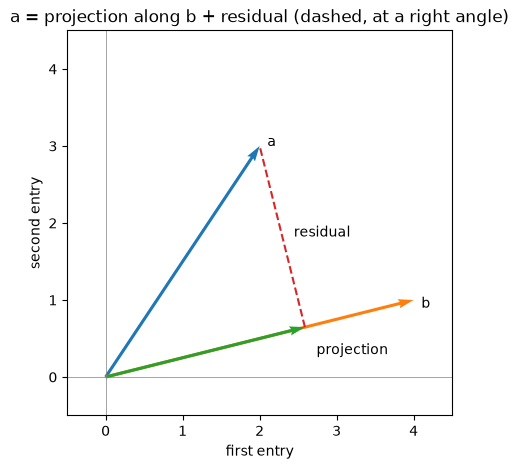

In [6]:
plt.figure(figsize=(5.5, 5))
origin = [0, 0, 0]
xs = [a[0], b[0], proj[0]]
ys = [a[1], b[1], proj[1]]
plt.quiver(origin, origin, xs, ys,
           angles="xy", scale_units="xy", scale=1,
           color=["C0", "C1", "C2"], width=0.008)
# The residual runs from the shadow's tip back up to a's tip:
plt.plot([proj[0], a[0]], [proj[1], a[1]], "C3--")
plt.text(a[0] + 0.1, a[1], "a")
plt.text(b[0] + 0.1, b[1] - 0.1, "b")
plt.text(proj[0] + 0.15, proj[1] - 0.35, "projection")
plt.text((proj[0] + a[0]) / 2 + 0.15, (proj[1] + a[1]) / 2, "residual")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 4.5)
plt.gca().set_aspect("equal")
plt.xlabel("first entry")
plt.ylabel("second entry")
plt.title("a = projection along b + residual (dashed, at a right angle)")
plt.show()

### Checkpoint 4

1. By hand: for your Checkpoint 3 projection of $a = (2, 3)$ onto
   $b = (1, 1)$, compute the residual and verify it is orthogonal to $b$.
2. Still by hand: verify the Pythagorean split
   $\|a\|^2 = \|\text{proj}\|^2 + \|r\|^2$ with exact numbers for that same
   example.

## 5. Many Points at Once: Batch Projection

**Motivation.**
The exam's signature NumPy move: take everything from Sections 3-4 and do it
for *every row of a 2-D array simultaneously*, with loops banned.
The F1 broadcasting toolkit makes the batch version barely longer than the
single-vector version.

**The recipe.**
For a 2-D array `Y` of shape `(n, d)` (one vector per row) and a unit
vector `u` of shape `(d,)`:

1. `reach = np.sum(Y * u, axis=1)` — all $n$ dot products with `u` at once,
   shape `(n,)`;
2. `P = reach[:, np.newaxis] * u` — reshape to `(n, 1)` so broadcasting
   scales `u` by a different amount per row, shape `(n, d)`;
3. `R = Y - P` — all $n$ residuals, and
   `np.sum(R * u, axis=1)` should be zeros — the orthogonality property,
   checkable for the whole batch with one `np.allclose`.

**Worked example.**

In [7]:
u = np.array([0.6, 0.8])                 # a unit vector
Y = np.array([[4.0, 3.0],
              [8.0, 6.0],
              [-3.0, -4.0],
              [5.0, 0.0]])

reach = np.sum(Y * u, axis=1)            # (4,)
P = reach[:, np.newaxis] * u             # (4, 1) * (2,) -> (4, 2)
R = Y - P

print("reach:", reach)
print("projections:\n", P)
print("all residuals orthogonal to u?",
      np.allclose(np.sum(R * u, axis=1), 0.0, atol=1e-12, rtol=0))

reach: [ 4.8  9.6 -5.   3. ]
projections:
 [[ 2.88  3.84]
 [ 5.76  7.68]
 [-3.   -4.  ]
 [ 1.8   2.4 ]]
all residuals orthogonal to u? True


### Checkpoint 5

1. Without running code: in the recipe above, what are the shapes of
   `Y * u`, `reach`, `reach[:, np.newaxis]`, and `P`?
2. Row 2 of `Y` is $(-3, -4)$, which lies exactly on the line through `u`.
   What is its residual row in `R`, and its `reach` value? (Read them off
   the printed output and explain both signs in one sentence.)

## 6. Worked Exam-Style Example

Constrained implementation tasks are the exam's signature register: an exact
identifier, a shape contract, banned APIs, and a zero-points clause.
Here is one solved in full, with the reasoning made explicit.

---

**Problem (coding; loops banned).**
Implement

```python
def unit_rows(X):
    ...
```

which takes a 2-D array `X` of shape `(n, d)` whose rows are all nonzero and
returns an array of the same shape in which every row has been rescaled to
unit Euclidean length.
**Rules:** `for`, `while`, and comprehensions are banned; `np.linalg.norm`
is banned; violating either rule scores zero.

---

**Solution.**

*Step 1 — plan the shapes before writing code.*
The row norms must be one number per row: shape `(n,)`.
To divide a `(n, d)` array row-by-row, the norms must broadcast as a
`(n, 1)` column against `(n, d)`.

*Step 2 — build the row norms from allowed pieces.*
`np.sqrt(np.sum(X**2, axis=1))` — squares elementwise, sums across each
row, roots: the Session 1 recipe, no banned function involved.

*Step 3 — reshape and divide.*

In [8]:
def unit_rows(X):
    norms = np.sqrt(np.sum(X**2, axis=1))   # (n,)
    return X / norms[:, np.newaxis]         # (n, d) / (n, 1) -> row by row


# Verify on rows with known norms 5, 13, 10:
X = np.array([[3.0, 4.0],
              [5.0, 12.0],
              [8.0, 6.0]])
U = unit_rows(X)
print(U)
print("row norms after:", np.sqrt(np.sum(U**2, axis=1)))   # all 1.0

[[0.6        0.8       ]
 [0.38461538 0.92307692]
 [0.8        0.6       ]]
row norms after: [1. 1. 1.]


*Step 4 — self-grade against the contract.*
Same shape in and out ✓; every output row has norm 1 ✓; no loops ✓; no
banned function ✓.
Testing on rows whose norms you know *exactly* (the 3-4-5, 5-12-13, and
6-8-10 triangles) is the habit that separates "runs" from "is right".

### Checkpoint 6

1. Adapt the reasoning: `project_rows(X, u)` must return the projection of
   every row of `X` (shape `(n, d)`) onto the unit vector `u` (shape
   `(d,)`). What shape must the intermediate array of dot products have,
   and where exactly does the `(n, 1)` reshape enter?
2. Why would `X / np.sqrt(np.sum(X**2))` (no `axis` argument) be wrong in
   `unit_rows`, even though it runs without error?

## 7. Common Pitfalls

**Pitfall 1 — projecting with a non-unit vector, no correction.**
The short formula $\text{proj} = (a\cdot b)\,b$ is only valid when $b$ is a
unit vector.
Used with a general $b$, it silently scales the shadow by $\|b\|^2$ — and
the residual stops being orthogonal, which is how you catch it:

In [9]:
a = np.array([3.0, 1.0])
b = np.array([2.0, 0.0])                 # NOT a unit vector

proj_broken = (a @ b) * b                # BROKEN: missing the /(b.b)
r_broken = a - proj_broken
print("broken projection:", proj_broken, "  r.b =", r_broken @ b)   # not 0!

proj_fixed = (a @ b) / (b @ b) * b       # fix: divide by b.b
r_fixed = a - proj_fixed
print("fixed  projection:", proj_fixed, "  r.b =", r_fixed @ b)     # 0

broken projection: [12.  0.]   r.b = -18.0
fixed  projection: [3. 0.]   r.b = 0.0


The broken shadow $(12, 0)$ is *longer than $a$ itself* — geometrically
impossible for a shadow.
Always run the free self-check: **the residual must be orthogonal to the
direction**; if $r\cdot b \neq 0$, the projection is wrong, full stop.

**Pitfall 2 — forgetting the `(n, 1)` reshape in batch formulas.**
In the batch recipe, `reach` has shape `(n,)` and `u` has shape `(d,)`.
Multiplying them directly either crashes (when $n \neq d$ — the lucky case)
or silently computes nonsense (when $n = d$):

In [10]:
u = np.array([0.6, 0.8])
Y = np.array([[4.0, 3.0],
              [8.0, 6.0],
              [-3.0, -4.0],
              [5.0, 0.0]])
reach = np.sum(Y * u, axis=1)            # shape (4,)

try:
    P_broken = reach * u                 # BROKEN: (4,) * (2,) cannot broadcast
except ValueError as e:
    print("ValueError:", e)

P_fixed = reach[:, np.newaxis] * u       # (4, 1) * (2,) -> (4, 2)
print("fixed shape:", P_fixed.shape)

ValueError: operands could not be broadcast together with shapes (4,) (2,) 
fixed shape: (4, 2)


The crash is the *lucky* failure — it points straight at the shape bug.
The dangerous case is a square batch (`n == d`), where `reach * u`
broadcasts happily and produces wrong numbers with no error at all.
The defense is the same shape-prediction habit as always: write the
expected shape as a comment *before* running the cell — and keep an
orthogonality `np.allclose` check at the end of any batch-projection
computation.

### Checkpoint 7

1. A classmate projects $a = (2, 2)$ onto $b = (3, 0)$ with
   $(a\cdot b)\,b$ and gets $(18, 0)$. What free check exposes the error,
   and what is the correct projection?
2. In the batch recipe with `Y` of shape `(2, 2)` (a square batch), why is
   the missing-reshape bug *worse* than with shape `(4, 2)`?

## Exam Connections

How this session's material shows up in Round 1 (paraphrased from the
`reference/analysis.md` topic table — no real test text here):

- The **linear-algebra cluster** — the largest block of exam sub-parts —
  makes projection/residual splits a recurring theme: residual lengths and
  unit-vector components requested in reduced normal forms
  ($p/q$ with $\gcd(p,q)=1$, or $\frac{1}{\sqrt a}(b, c)$ with
  $\gcd(b,c)=1$), with reasoning-required flags on the derivation steps.
  Practice p14, p15, and p18 rehearse exactly that register.
- The **NumPy implementation cluster** poses batch normalization and
  batch projection over rows — Section 5 and Section 6's task shape — with
  loops banned, shape contracts stated, and zero-point clauses for banned
  APIs. Practice p06, p10, p16, and p17 train it.
- Orthogonality checks (`np.allclose` on a batch of dot products) appear as
  self-verification steps inside larger problems; building that reflex is
  the point of the residual property.

## Going Deeper

Optional forward pointers along the course map — nothing here is needed for
this unit's practice:

- **`F3-matrices`** (next in the foundation track) treats a 2-D array as a
  *machine that transforms vectors*.
  Everything there is built from this unit's dot products, and the
  orthonormal "custom axes" of Section 2 return as the best-behaved
  machines of all.
- **`C8-embeddings`** (core track) represents pieces of text as vectors and
  compares them — at scale — with exactly the cosine similarity and batch
  row-wise computations you just learned.
  The word-count examples of Session 2 are the hand-sized version of that
  world.

## Checkpoint Answers

<details><summary><b>Checkpoint 1</b></summary>

1. (i) $2 - 2 = 0$: orthogonal. (ii) $2 + 2 = 4$: not orthogonal.
   (iii) $6 - 4 - 2 = 0$: orthogonal.
2. $3x + 2 = 0$, so $x = -\tfrac23$.

</details>

<details><summary><b>Checkpoint 2</b></summary>

1. Both vectors have norm $\sqrt5$, so take
   $u_1 = \left(\tfrac{1}{\sqrt5}, \tfrac{2}{\sqrt5}\right)$ and
   $u_2 = \left(\tfrac{2}{\sqrt5}, -\tfrac{1}{\sqrt5}\right)$.
2. $t_1 = v\cdot u_1 = 10/\sqrt5$ and $t_2 = v\cdot u_2 = 5/\sqrt5$; then
   $t_1 u_1 + t_2 u_2 = (2, 4) + (2, -1) = (4, 3) = v$. ✓

</details>

<details><summary><b>Checkpoint 3</b></summary>

1. $a\cdot b = 5$, $b\cdot b = 2$:
   $\text{proj} = \tfrac52\,(1, 1) = (2.5,\ 2.5)$.
2. The shadow of an arrow already on the line is the arrow itself:
   projection $= a$. Check: $a = 5\,\hat b = (3, 4)$ gives
   $a\cdot\hat b = 5$ and $\text{proj} = 5\,\hat b = (3, 4) = a$.

</details>

<details><summary><b>Checkpoint 4</b></summary>

1. $r = (2, 3) - (2.5,\ 2.5) = (-0.5,\ 0.5)$, and
   $r\cdot b = -0.5 + 0.5 = 0$. ✓
2. $\|a\|^2 = 13$, $\|\text{proj}\|^2 = 6.25 + 6.25 = 12.5$,
   $\|r\|^2 = 0.25 + 0.25 = 0.5$, and $13 = 12.5 + 0.5$. ✓

</details>

<details><summary><b>Checkpoint 5</b></summary>

1. `Y * u` → `(4, 2)`; `reach` → `(4,)`; `reach[:, np.newaxis]` → `(4, 1)`;
   `P` → `(4, 2)`.
2. Residual row $(0, 0)$ and reach $-5$: the point lies on the line (so
   nothing is left over), but on the *opposite* side of the origin from
   `u`, so its shadow reaches backwards.

</details>

<details><summary><b>Checkpoint 6</b></summary>

1. The dot products `np.sum(X * u, axis=1)` have shape `(n,)`; the reshape
   to `(n, 1)` enters when scaling `u`:
   `np.sum(X * u, axis=1)[:, np.newaxis] * u`, so each row of the output is
   its own multiple of `u`.
2. Without `axis=1`, the sum collapses the *entire array* to one number —
   every row gets divided by the same overall value, so the output rows are
   not unit vectors (and the bug raises no error, which is what makes it
   dangerous).

</details>

<details><summary><b>Checkpoint 7</b></summary>

1. The residual check: $r = (2,2) - (18, 0) = (-16, 2)$ has
   $r\cdot b = -48 \neq 0$, so the projection is wrong.
   Correct: $\frac{a\cdot b}{b\cdot b}\,b = \frac{6}{9}(3, 0) = (2, 0)$
   (residual $(0, 2)$, orthogonal ✓).
2. With a square batch, `reach * u` has compatible shapes, so NumPy raises
   no error — the wrong numbers flow silently downstream, and only a
   shape-prediction habit or an orthogonality check catches them.

</details>

---

**End of the lesson sessions.**
Next: the practice sets (see the unit overview in `lesson.ipynb` for the
recommended order), and `review.ipynb` when you are ready to consolidate.